In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np, scipy, seaborn as sns, graphviz
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from itertools import product
from random import sample
from hyperopt import fmin, tpe, Trials, STATUS_OK, hp

# Load and preprocess dataset
df = pd.read_csv('/content/credit-card-full.csv').drop(columns='ID')
X = df.drop(columns='default payment next month')
y = df['default payment next month']

# Create dummies for categorical columns
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True, dtype='uint8')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

# **Hyperparameter Tuning in Python**

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Load and preprocess dataset
df = pd.read_csv('/content/credit-card-full.csv').drop(columns='ID')
X = df.drop(columns='default payment next month')
y = df['default payment next month']

# Create dummies for categorical columns
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True, dtype='uint8')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

# Logistic Regression wrapped in OneVsRestClassifier
lr = LogisticRegression(max_iter=999999, solver='liblinear').fit(X_train, y_train)

## **Parameters in Logistic Regression**

In [ ]:
print(lr.coef_)

[[-5.29990523e-06 -1.00283795e-04  7.12398738e-06  5.59486588e-06
   4.84716619e-06  4.54282408e-06  4.26674780e-06  3.98224459e-06
  -1.16804622e-05  5.56432369e-06  3.01126818e-06  1.90660335e-06
   3.25349747e-06  2.29116598e-06 -3.63673383e-05 -2.97384291e-05
  -1.14562449e-05 -1.04686485e-05 -6.66507739e-06 -1.80384527e-06
  -2.35848368e-06 -6.64327975e-07 -1.65697578e-06 -7.17422842e-07
  -3.77463799e-08 -1.18812354e-07 -1.22151827e-08 -6.69978240e-07
  -2.46621273e-06 -5.10083897e-08]]


## **Tidy up the coefficients**

In [ ]:
# Get the original variable names
original_variables = list(X.columns)

# Zip together the names and coefficients
zipped_together = list(zip(original_variables, lr.coef_[0]))
coefs = [list(x) for x in zipped_together]

# Put into a DataFrame with column labels
coefs = pd.DataFrame(coefs, columns=["Variable", "Coefficient"])

# Now sort and print the top three coefficients
coefs.sort_values(by=["Coefficient"], axis=0, inplace=True, ascending=False)
print(coefs.head(3))

  Variable  Coefficient
2    PAY_0     0.000837
3    PAY_2     0.000659
4    PAY_3     0.000570


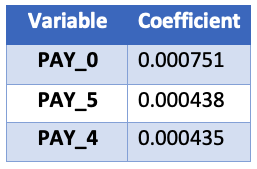

Having a high number of months of delayed payments make someone more likely to default next month.

## **Parameters in Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(max_depth=2, random_state=123)
rf_clf.fit(X_train, y_train)

# Pull out one tree from the forest
chosen_tree = rf_clf.estimators_[7]

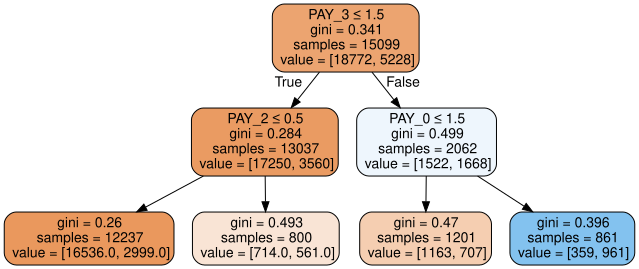

In [ ]:
import graphviz
from sklearn.tree import export_graphviz

tree_graph = export_graphviz(chosen_tree, out_file=None,
                                  feature_names=list(X.columns),
                                  filled=True, rounded=True,
                                  special_characters=True) #Names of each of the target classes in ascending numerical order.
display(graphviz.Source(tree_graph))

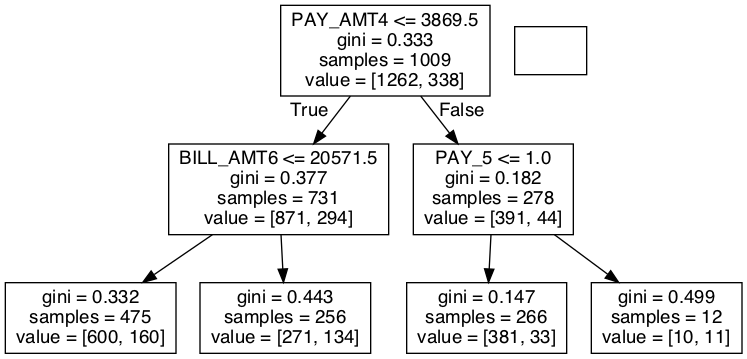

## **Extracting node decisions**

In [ ]:
# Get the column it split on
split_column = chosen_tree.tree_.feature[1]
split_column_name = X_train.columns[split_column]

# Get the level it split on
split_value = chosen_tree.tree_.threshold[1]
print("This node split on feature {}, at a value of {}".format(split_column_name, split_value))

`"This node split on feature PAY_0, at a value of 1.5"`

The figure might be different due to random_state.  The logistic regression above differs probably due to sklearn version?

### ***Exercise: Extracting a Logistic Regression parameter***
You are now going to practice extracting an important parameter of the logistic regression model. The logistic regression has a few other parameters you will not explore here but you can review them in the scikit-learn.org documentation for the LogisticRegression() module under 'Attributes'.

This parameter is important for understanding the direction and magnitude of the effect the variables have on the target.

In this exercise we will extract the coefficient parameter (found in the coef_ attribute), zip it up with the original column names, and see which variables had the largest positive effect on the target variable.

#### **Instructions**

- Create a list of the original column names used in the training DataFrame.
- Extract the coefficients of the logistic regression estimator.
- Create a DataFrame of coefficients and variable names & view it.
- Print out the top 3 'positive' variables based on the coefficient size.

In [ ]:
log_reg_clf = LogisticRegression(max_iter=999999, solver='liblinear').fit(X_train, y_train)

# Create a list of original variable names from the training DataFrame
original_variables = list(X_train.columns)

# Extract the coefficients of the logistic regression estimator
model_coefficients = log_reg_clf.coef_[0]

# Create a dataframe of the variables and coefficients & print it out
coefficient_df = pd.DataFrame({"Variable" : original_variables, "Coefficient": model_coefficients})
print(coefficient_df)

# Print out the top 3 positive variables
top_three_df = coefficient_df.sort_values(by="Coefficient", axis=0, ascending=False).iloc[0:3]
print(top_three_df)

       Variable  Coefficient
0     LIMIT_BAL    -0.000004
1           AGE    -0.008664
2         PAY_0     0.000837
3         PAY_2     0.000659
4         PAY_3     0.000570
5         PAY_4     0.000528
6         PAY_5     0.000491
7         PAY_6     0.000455
8     BILL_AMT1    -0.000010
9     BILL_AMT2     0.000005
10    BILL_AMT3     0.000003
11    BILL_AMT4     0.000002
12    BILL_AMT5     0.000003
13    BILL_AMT6     0.000002
14     PAY_AMT1    -0.000031
15     PAY_AMT2    -0.000025
16     PAY_AMT3    -0.000010
17     PAY_AMT4    -0.000009
18     PAY_AMT5    -0.000006
19     PAY_AMT6    -0.000002
20        SEX_2    -0.000233
21  EDUCATION_1    -0.000067
22  EDUCATION_2    -0.000152
23  EDUCATION_3    -0.000060
24  EDUCATION_4    -0.000004
25  EDUCATION_5    -0.000013
26  EDUCATION_6    -0.000001
27   MARRIAGE_1    -0.000039
28   MARRIAGE_2    -0.000253
29   MARRIAGE_3    -0.000004
  Variable  Coefficient
2    PAY_0     0.000837
3    PAY_2     0.000659
4    PAY_3     0.000570


### ***Exercise: Extracting a Random Forest parameter***

You will now translate the work previously undertaken on the logistic regression model to a random forest model. A parameter of this model is, for a given tree, how it decided to split at each level.

This analysis is not as useful as the coefficients of logistic regression as you will be unlikely to ever explore every split and every tree in a random forest model. However, it is a very useful exercise to peek under the hood at what the model is doing.

In this exercise we will extract a single tree from our random forest model, visualize it and programmatically extract one of the splits.

#### ***Instructions***

- Extract the 7th tree (6th index) from the random forest model.
- Visualize this tree (`tree_viz_image`) to see the split decisions.
- Extract the feature & level of the top split.
- Print out the feature and level together.

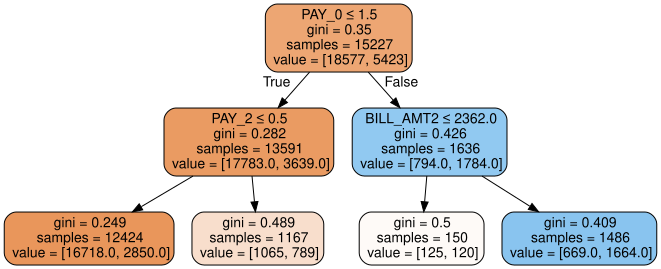

This node split on feature PAY_0, at a value of 1.5


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import graphviz
from sklearn.tree import export_graphviz

rf_clf = RandomForestClassifier(max_depth=2, random_state=123)
rf_clf.fit(X_train, y_train)

# Extract the 7th (index 6) tree from the random forest
chosen_tree = rf_clf.estimators_[6]

# Visualize the graph using the provided image
# imgplot = plt.imshow(tree_viz_image)
# plt.show()

tree_graph = export_graphviz(chosen_tree, out_file=None,
                                  feature_names=list(X.columns),
                                  filled=True, rounded=True,
                                  special_characters=True) #Names of each of the target classes in ascending numerical order.
display(graphviz.Source(tree_graph))

# Extract the parameters and level of the top (index 0) node
split_column = chosen_tree.tree_.feature[0]
split_column_name = X_train.columns[split_column]
split_value = chosen_tree.tree_.threshold[0]

# Print out the feature and level
print("This node split on feature {}, at a value of {}".format(split_column_name, split_value))

# **Hyperparameters**

### ***Exercise: Exploring Random Forest Hyperparameters***

You will now assess an existing random forest model (it has some bad choices for hyperparameters!) and then make better choices for a new random forest model and assess its performance.


####Instructions####

- Print out the hyperparameters of the existing random forest classifier by printing the estimator and then create a confusion matrix and accuracy score from it. The test set `y_test` and the old predictions `rf_old_predictions` will be quite useful!

- Create a new random forest classifier with a better `n_estimators` (try 500) then fit this to the data and obtain predictions.

- Assess the performance of the new random forest classifier. Create the confusion matrix and accuracy score and print them out. How does this compare to the first model you were given?

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf_old = RandomForestClassifier(n_estimators=5, random_state=42).fit(X_train, y_train)
rf_old_predictions = rf_clf_old.predict(X_test)

# Print out the old estimator, notice which hyperparameter is badly set
print(rf_clf_old)

# Get confusion matrix & accuracy for the old rf_model
print("Confusion Matrix: \n\n {} \n Accuracy Score: \n\n {}".format(
  confusion_matrix(y_test, rf_old_predictions),
  accuracy_score(y_test, rf_old_predictions)))

# Create a new random forest classifier with better hyperparamaters
rf_clf_new = RandomForestClassifier(n_estimators=500)

# Fit this to the data and obtain predictions
rf_new_predictions = rf_clf_new.fit(X_train, y_train).predict(X_test)

# Assess the new model (using new predictions!)
print("Confusion Matrix: \n\n", confusion_matrix(y_test, rf_new_predictions))
print("Accuracy Score: \n\n", accuracy_score(y_test, rf_new_predictions))

RandomForestClassifier(n_estimators=5, random_state=42)
Confusion Matrix: 

 [[4210  463]
 [ 858  469]] 
 Accuracy Score: 

 0.7798333333333334
Confusion Matrix: 

 [[4422  251]
 [ 840  487]]
Accuracy Score: 

 0.8181666666666667


We got a nice 4% accuracy boost just from changing the `n_estimators`. You have had your first taste of hyperparameter tuning for a random forest model.

### ***Exercise: Hyperparameters of KNN***

To apply the concepts learned in the prior exercise, it is good practice to try out learnings on a new algorithm. The k-nearest-neighbors algorithm is not as popular as it used to be but can still be an excellent choice for data that has groups of data that behave similarly. Could this be the case for our credit card users?

In this case you will try out several different values for one of the core hyperparameters for the knn algorithm and compare performance.

#### **Instructions**
- Build a knn estimator for the following values of `n_neighbors` [5,10,20].

- Fit each to the training data and produce predictions.

- Get an accuracy score for each model and print them out.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Build a knn estimator for each value of n_neighbours
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_20 = KNeighborsClassifier(n_neighbors=20)

# Fit each to the training data & produce predictions
knn_5_predictions = knn_5.fit(X_train, y_train).predict(X_test)
knn_10_predictions = knn_10.fit(X_train, y_train).predict(X_test)
knn_20_predictions = knn_20.fit(X_train, y_train).predict(X_test)

# Get an accuracy score for each of the models
knn_5_accuracy = accuracy_score(y_test, knn_5_predictions)
knn_10_accuracy = accuracy_score(y_test, knn_10_predictions)
knn_20_accuracy = accuracy_score(y_test, knn_20_predictions)
print("The accuracy of 5, 10, 20 neighbours was {}, {}, {}".format(knn_5_accuracy, knn_10_accuracy, knn_20_accuracy))

The accuracy of 5, 10, 20 neighbours was 0.755, 0.7746666666666666, 0.7801666666666667


 You successfully tested 3 different options for 1 hyperparameter, but it was pretty exhausting. Next, we will try to find a way to make this easier.

 # **Hyperparameter Values**

## **Conflicting hyperparameter choices**

- **`LogisticRegression()`** conflicting parameter options of solver & penalty that conflict.

The `'newton-cg'`, `'saga'` and `'lbfgs'` solvers support only l2 penalties.



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Set the learning rates & results storage
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
results_list = []

# Create the for loop to evaluate model predictions for each learning rate
for learning_rate in learning_rates:
    model = GradientBoostingClassifier(learning_rate=learning_rate)
    predictions = model.fit(X_train, y_train).predict(X_test)

    # Save the learning rate and accuracy score
    results_list.append(accuracy_score(y_test, predictions))

# Gather everything into a DataFrame
results_df = pd.DataFrame(data={'learning_rate':learning_rates, 'accuracy':results_list})
print(results_df)

   learning_rate  accuracy
0          0.001  0.778833
1          0.010  0.821667
2          0.050  0.822500
3          0.100  0.822333
4          0.200  0.822000
5          0.500  0.813333


Here, it seems that a learning rate of 0.05 yields the best accuracy.

### ***Exercise: Building Learning Curves***

If we want to test many different values for a single hyperparameter it can be difficult to easily view that in the form of a DataFrame. Previously you learned about a nice trick to analyze this. A graph called a 'learning curve' can nicely demonstrate the effect of increasing or decreasing a particular hyperparameter on the final result.

Instead of testing only a few values for the learning rate, you will test many to easily see the effect of this hyperparameter across a large range of values. A useful function from NumPy is **`np.linspace(start, end, num)`** which allows you to create a number of values (`num`) evenly spread within an interval (`start`, `end`) that you specify.

### ***Instructions***

- Create a list of 30 learning rates evenly spread between 0.01 and 2.

- Create a similar loop to last exercise but just save out accuracy scores to a list.

- Plot the learning rates against the accuracy score.

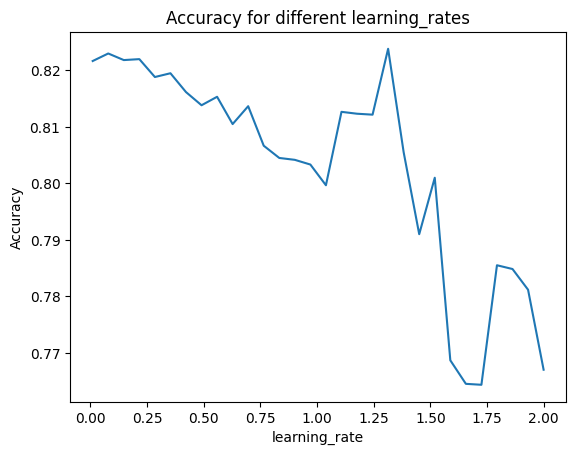

In [ ]:
# Set the learning rates & accuracies list
learn_rates = np.linspace(0.01, 2, num=30)
accuracies = []

# Create the for loop
for learn_rate in learn_rates:
  	# Create the model, predictions & save the accuracies as before
    model = GradientBoostingClassifier(learning_rate=learn_rate)
    predictions = model.fit(X_train, y_train).predict(X_test)
    accuracies.append(accuracy_score(y_test, predictions))

# Plot results
plt.plot(learn_rates, accuracies)
plt.gca().set(xlabel='learning_rate', ylabel='Accuracy', title='Accuracy for different learning_rates')
plt.show()

You can see that for low values, you get a pretty good accuracy. However once the learning rate pushes much above 1.5, the accuracy starts to drop.

# **Grid Search**

### ***Exercise: Build Grid Search functions***

In data science it is a great idea to try building algorithms, models and processes 'from scratch' so you can really understand what is happening at a deeper level. Of course there are great packages and libraries for this work (and we will get to that very soon!) but building from scratch will give you a great edge in your data science work.

In this exercise, you will create a function to take in 2 hyperparameters, build models and return results. You will use this function in a future exercise.

#### ***Instructions***

* Build a function that takes two parameters called `learning_rate` and `max_depth` for the learning rate and maximum depth.

* Add capability in the function to build a GBM model and fit it to the data with the input hyperparameters.

* Have the function return the results of that model and the chosen hyperparameters (`learning_rate` and `max_depth`).

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def gbm_grid_search(learning_rate, max_depth):

	# Create the model
    model = GradientBoostingClassifier(learning_rate=learning_rate, max_depth=max_depth)

    # Use the model to make predictions
    predictions = model.fit(X_train, y_train).predict(X_test)

    # Return the hyperparameters and score
    return([learning_rate, max_depth, accuracy_score(y_test, predictions)])

### ***Exercise: Iteratively tune multiple hyperparameters***

In this exercise, you will build on the function you previously created to take in 2 hyperparameters, build a model and return the results. You will now use that to loop through some values and then extend this function and loop with another hyperparameter.

#### ***Instructions***

Write a for-loop to test the values (0.01, 0.1, 0.5) for the `learning_rate` and (2, 4, 6) for the `max_depth` using the function you created `gbm_grid_search` and print the results.

- Extend the `gbm_grid_search` function to include the hyperparameter subsample. Name this new function `gbm_grid_search_extended`

- Extend your loop to call `gbm_grid_search`, then test the values `[0.4 , 0.6]` for the subsample hyperparameter and print the results.

In [ ]:
# Create the relevant lists
results_list = []
learn_rate_list = [0.01, 0.1, 0.5]
max_depth_list = [2, 4, 6]

# Create the for loop
for learn_rate in learn_rate_list:
    for max_depth in max_depth_list:
        results_list.append(gbm_grid_search(learn_rate,max_depth))

# Print the results
print(results_list)

[[0.01, 2, 0.821], [0.01, 4, 0.8191666666666667], [0.01, 6, 0.8151666666666667], [0.1, 2, 0.823], [0.1, 4, 0.822], [0.1, 6, 0.8218333333333333], [0.5, 2, 0.8205], [0.5, 4, 0.8071666666666667], [0.5, 6, 0.7916666666666666]]


In [ ]:
# Extend the function input
def gbm_grid_search_extended(learn_rate, max_depth, subsample):

	# Extend the model creation section
    model = GradientBoostingClassifier(learning_rate=learn_rate, max_depth=max_depth, subsample=subsample)

    predictions = model.fit(X_train, y_train).predict(X_test)

    # Extend the return part
    return([learn_rate, max_depth, subsample, accuracy_score(y_test, predictions)])

results_list = []

# Create the new list to test
subsample_list = [0.4, 0.6]

for learn_rate in learn_rate_list:
    for max_depth in max_depth_list:

    	# Extend the for loop
        for subsample in subsample_list:

            # Extend the results to include the new hyperparameter
            results_list.append(gbm_grid_search_extended(learn_rate, max_depth, subsample))

# Print results
print(results_list)

[[0.01, 2, 0.4, 0.815], [0.01, 2, 0.6, 0.8205], [0.01, 4, 0.4, 0.8185], [0.01, 4, 0.6, 0.8193333333333334], [0.01, 6, 0.4, 0.8161666666666667], [0.01, 6, 0.6, 0.818], [0.1, 2, 0.4, 0.822], [0.1, 2, 0.6, 0.8218333333333333], [0.1, 4, 0.4, 0.8228333333333333], [0.1, 4, 0.6, 0.821], [0.1, 6, 0.4, 0.819], [0.1, 6, 0.6, 0.8185], [0.5, 2, 0.4, 0.8196666666666667], [0.5, 2, 0.6, 0.8211666666666667], [0.5, 4, 0.4, 0.8063333333333333], [0.5, 4, 0.6, 0.8051666666666667], [0.5, 6, 0.4, 0.7885], [0.5, 6, 0.6, 0.7771666666666667]]


# **Grid Search with Scikit Learn**

## **Steps in a Grid Search**

1. An algorithm to tune the hyperparameters. (Sometimes called an 'estimator')
2. Defining which hyperparameters we will tune
3. Defining a range of values for each hyperparameter
4. Setting a cross-validation scheme; and
5. Define a score function so we can decide which square on our grid was 'the best'.
6. Include extra useful information or functions

## **GridSearchCV `'estimator'`**

The estimator input:
- Essentially our algorithm
- You have already worked with KNN, Random Forest, GBM, Logistic Regression

## **GridSearchCV `'param_grid'`**

In [ ]:
param_grid = {'max_depth': [2, 4, 6, 8], 'min_samples_leaf': [1, 2, 4, 6]}

## **GridSearchCV `'cv'`**

- Choice of how to undertake cross-validation
- Using an integer undertakes k-fold cross validation where 5 or 10 is usually standard

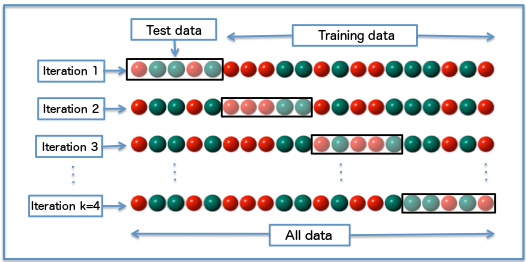

## **GridSearchCV `'scoring'`**

The scoring input:
Which score to use to choose the best grid square (model)

## **GridSearchCV `'refit'`**

The refit input:
- Fits the best hyperparameters to the training data
- Allows the GridSearchCV object to be used as an estimator (for prediction)

## **GridSearchCV `'n_jobs'`**

- Assists with parallel execution
- Allows multiple models to be created at the same time, rather than one after the other


In [ ]:
grid_rf_class = GridSearchCV(estimator=rf_class,
                             param_grid=parameter_grid,
                             scoring='accuracy',
                             n_jobs=4,
                             cv = 10,
                             refit=True,
                             return_train_score=True)

## **Using a GridSearchCV Object**

In [ ]:
#Fit the object to our data
grid_rf_class.fit(X_train, y_train)

# Make predictions
grid_rf_class.predict(X_test)

### ***Example***

In [ ]:
from sklearn.model_selection import GridSearchCV

# Create a Random Forest Classifier with specified criterion
rf_class = RandomForestClassifier(criterion='entropy')

# Create the parameter grid
param_grid = {'max_depth': [2, 4, 8, 15], 'max_features': ['log2','sqrt']}

# Create a GridSearchCV object
grid_rf_class = GridSearchCV(
    estimator=rf_class,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=4,
    cv=5,
    refit=True, return_train_score=True)

print(grid_rf_class)

GridSearchCV(cv=5, estimator=RandomForestClassifier(criterion='entropy'),
             n_jobs=4,
             param_grid={'max_depth': [2, 4, 8, 15],
                         'max_features': ['log2', 'sqrt']},
             return_train_score=True, scoring='roc_auc')


# **Understanding a grid search output**


## **`.cv_results_`**

In [ ]:
pd.DataFrame(grid_rf_class.cv_results_)

* **`best_params_`** , the dictionary of parameters that gave the best score.

* **`best_score_`** , the actual best score.

* The **`best_estimator_`** property is an estimator built using the best parameters from the grid vsearch.

### ***Exercise: Exploring the grid search results***

You will now explore the **`cv_results_`** property of the GridSearchCV object. This is a dictionary that we can read into a pandas DataFrame and contains a lot of useful information about the grid search we just undertook.

A reminder of the different column types in this property:

* `time_` columns
* `param`_ columns (one for each hyperparameter) and the singular `params` column (with all hyperparameter settings)
* a `train_score` column for each cv fold including the `mean_train_score` and `std_train_score` columns
* a `test_score` column for each cv fold including the `mean_test_score` and `std_test_score` columns
a `rank_test_score` column with a number from 1 to n (number of iterations) ranking the rows based on their `mean_test_score`

### ***Instructions***

* Read the `cv_results_` property of the `grid_rf_class` GridSearchCV object into a data frame & print the whole thing out to inspect.

* Extract & print the singular column containing a dictionary of all hyperparameters used in each iteration of the grid search.

* Extract & print the row that had the best mean test score by indexing using the `rank_test_score` column.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Create a Random Forest Classifier with specified criterion
rf_class = RandomForestClassifier(criterion='entropy')

# Create the parameter grid
param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'n_estimators': [100, 200, 300]}

# Create a GridSearchCV object
grid_rf_class = GridSearchCV(estimator=rf_class,
                             param_grid=param_grid,
                             scoring='roc_auc',
                             n_jobs=10,
                             cv=5,
                             error_score='raise',
                             refit=True,
                             return_train_score=True)

grid_rf_class.fit(X, y)

# Read the cv_results property into a dataframe & print it out
cv_results_df = pd.DataFrame(grid_rf_class.cv_results_)
display(cv_results_df)

# Extract and print the column with a dictionary of hyperparameters used
column = cv_results_df.loc[:, "params"]
display(column)

# Extract and print the row that had the best mean test score
best_row = cv_results_df[cv_results_df["rank_test_score"]==1]
display(best_row)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,60.593987,0.413417,0.528520,0.025213,10,1,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.756943,0.753392,...,0.779533,0.020104,6,0.863381,0.862837,0.859830,0.858566,0.854681,0.859859,0.003154
1,123.492573,1.836676,1.051068,0.117938,10,1,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.758106,0.755590,...,0.781623,0.020422,1,0.863215,0.864210,0.859485,0.856522,0.855381,0.859763,0.003506
2,191.714450,2.712871,1.551201,0.189218,10,1,300,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.758402,0.755763,...,0.781383,0.020078,2,0.862835,0.864511,0.861310,0.856447,0.854568,0.859934,0.003800
3,63.576846,1.907935,0.730393,0.060321,10,2,100,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",0.757255,0.756984,...,0.781154,0.019760,3,0.858193,0.859307,0.856889,0.852870,0.852205,0.855893,0.002852
4,118.012511,1.344686,0.973958,0.092308,10,2,200,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",0.758035,0.756553,...,0.781129,0.019669,4,0.861554,0.862326,0.857455,0.854309,0.852595,0.857648,0.003843
5,168.757883,2.137104,1.617185,0.369785,10,2,300,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",0.757469,0.754351,...,0.780710,0.020449,5,0.860493,0.860839,0.857677,0.853795,0.850915,0.856744,0.003856
6,90.739973,0.899908,1.053449,0.210776,20,1,100,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",0.753594,0.747219,...,0.773277,0.019394,12,0.997180,0.997224,0.997240,0.996737,0.996533,0.996983,0.000292
7,182.346352,2.800065,2.267859,0.265681,20,1,200,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",0.754832,0.751944,...,0.776547,0.019620,10,0.997488,0.997650,0.997671,0.996988,0.996585,0.997276,0.000424
8,274.142691,3.704775,3.197711,0.458157,20,1,300,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",0.756973,0.749994,...,0.777043,0.019760,9,0.997542,0.997745,0.997551,0.997076,0.996885,0.997360,0.000324
9,88.556437,0.888634,1.142283,0.302296,20,2,100,"{'max_depth': 20, 'min_samples_leaf': 2, 'n_es...",0.751463,0.749738,...,0.774793,0.020182,11,0.991895,0.992575,0.992446,0.991522,0.991341,0.991956,0.000489


,params
0,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es..."
1,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es..."
2,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es..."
3,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es..."
4,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es..."
5,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es..."
6,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es..."
7,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es..."
8,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es..."
9,"{'max_depth': 20, 'min_samples_leaf': 2, 'n_es..."


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
1,123.492573,1.836676,1.051068,0.117938,10,1,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.758106,0.75559,...,0.781623,0.020422,1,0.863215,0.86421,0.859485,0.856522,0.855381,0.859763,0.003506


### ***Exercise: Analyzing the best results***

At the end of the day, we primarily care about the best performing `'square'` in a grid search. Luckily Scikit Learn's gridSearchCv objects have a number of parameters that provide key information on just the best square (or row in `cv_results_`).

Three properties you will explore are:

* `best_score_` – The score (here ROC_AUC) from the best-performing square.
* `best_index_` – The index of the row in `cv_results_` containing information on the best-performing square.
- `best_params_` – A dictionary of the parameters that gave the best score, for example `'max_depth': 10`



### ***Instructions***

* Extract and print out the ROC_AUC score from the best performing square in `grid_rf_class`.

* Create a variable from the best-performing row by indexing into `cv_results_df`.

* Create a variable, `best_n_estimators` by extracting the `n_estimators` parameter from the best-performing square in `grid_rf_class` and print it out.

In [17]:
# Print out the ROC_AUC score from the best-performing square
best_score = grid_rf_class.best_score_
display(best_score)

# Create a variable from the row related to the best-performing square
cv_results_df = pd.DataFrame(grid_rf_class.cv_results_)
best_row = cv_results_df.loc[[grid_rf_class.best_index_]]
display(best_row)

# Get the n_estimators parameter from the best-performing square and print
best_n_estimators = grid_rf_class.best_params_["n_estimators"]
display(best_n_estimators)

np.float64(0.7816226304717524)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
1,123.492573,1.836676,1.051068,0.117938,10,1,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.758106,0.75559,...,0.781623,0.020422,1,0.863215,0.86421,0.859485,0.856522,0.855381,0.859763,0.003506


200

### ***Exercise: Using the best results***

While it is interesting to analyze the results of our grid search, our final goal is practical in nature; we want to make predictions on our test set using our estimator object.

We can access this object through the `best_estimator_` property of our grid search object.

Let's take a look inside the `best_estimator_ `property, make predictions, and generate evaluation scores.

We will firstly use the default `predict` (giving class predictions), but then we will need to use `predict_proba` rather than `predict` to generate the roc-auc score as roc-auc needs probability scores for its calculation. We use a slice `[:,1]` to get probabilities of the positive class.

#### ***Instructions***

* Check the type of the `best_estimator_` property.

* Use the `best_estimator_` property to make predictions on our test set.

* Generate a confusion matrix and ROC_AUC score from our predictions.


In [20]:
# See what type of object the best_estimator_ property is
print(type(grid_rf_class.best_estimator_))

# Create an array of predictions directly using the best_estimator_ property
predictions = grid_rf_class.best_estimator_.predict(X_test)

# Take a look to confirm it worked, this should be an array of 1's and 0's
print(predictions[0:5])

# Now create a confusion matrix
print("Confusion Matrix \n", confusion_matrix(y_test, predictions))

# Get the ROC-AUC score
predictions_proba = grid_rf_class.best_estimator_.predict_proba(X_test)[:,1]
print("ROC-AUC Score \n", roc_auc_score(y_test, predictions_proba))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
[0 0 1 0 0]
Confusion Matrix 
 [[4525  148]
 [ 783  544]]
ROC-AUC Score 
 0.8529608030612776


The `.best_estimator_` property is a really powerful property to understand for streamlining your machine learning model building process.

# **Random Search**

### ***Exercise: Randomly Sample Hyperparameters***

To undertake a random search, we firstly need to undertake a random sampling of our hyperparameter space.

In this exercise, you will firstly create some lists of hyperparameters that can be zipped up to a list of lists. Then you will randomly sample hyperparameter combinations in preparation for running a random search.

You will use just the hyperparameters `learning_rate` and `min_samples_leaf` of the GBM algorithm to keep the example illustrative and not overly complicated.

#### ***Instructions***

* Create a list of 200 values for the `learning_rate` hyperparameter between 0.01 and 1.5 and assign to the list `learn_rate_list`.
* Create a list of values between 10 and 40 inclusive for the hyperparameter `min_samples_leaf` and assign to the list `min_samples_list`.
* Combine these lists into a list of lists to sample from.
* Randomly sample 250 models from these hyperparameter combinations and print the result.

In [2]:
# Create a list of values for the learning_rate hyperparameter
learn_rate_list = list(np.linspace(0.01, 1.5, 200))

# Create a list of values for the min_samples_leaf hyperparameter
min_samples_list = list(range(10, 41))

# Combination list
combinations_list = [list(x) for x in product(learn_rate_list, min_samples_list)]

# Sample hyperparameter combinations for a random search.
random_combinations_index = np.random.choice(range(0, len(combinations_list)), 250, replace=False)
combinations_random_chosen = [combinations_list[x] for x in random_combinations_index]

# Print the result
print(combinations_random_chosen)

[[np.float64(0.10733668341708542), 24], [np.float64(0.9908542713567839), 13], [np.float64(0.5640703517587939), 26], [np.float64(0.45175879396984925), 39], [np.float64(0.5041708542713568), 18], [np.float64(1.2079899497487436), 13], [np.float64(1.3203015075376885), 28], [np.float64(0.7812060301507537), 20], [np.float64(0.6464321608040201), 33], [np.float64(0.8111557788944723), 30], [np.float64(1.4401005025125628), 15], [np.float64(1.350251256281407), 37], [np.float64(1.1406030150753768), 30], [np.float64(1.3802010050251257), 38], [np.float64(0.3094974874371859), 35], [np.float64(0.5266331658291458), 28], [np.float64(1.050753768844221), 17], [np.float64(0.4966834170854271), 20], [np.float64(0.1672361809045226), 25], [np.float64(1.5), 33], [np.float64(0.15974874371859296), 40], [np.float64(1.222964824120603), 18], [np.float64(0.945929648241206), 15], [np.float64(0.1822110552763819), 10], [np.float64(0.3993467336683417), 14], [np.float64(0.7287939698492463), 24], [np.float64(0.9833668341708

### ***Exercise: Randomly Search with Random Forest***

To solidify your knowledge of random sampling, let's try a similar exercise but using different hyperparameters and a different algorithm.

As before, create some lists of hyperparameters that can be zipped up to a list of lists. You will use the hyperparameters `criterion`, `max_depth` and `max_features` of the random forest algorithm. Then you will randomly sample hyperparameter combinations in preparation for running a random search.

You will use a slightly different package for sampling in this task, **`random.sample()`**.

#### ***Instructions***

* Create lists of the values `'gini'` and `'entropy'` for `criterion` & `"auto"`, `"sqrt"`, `"log2"`, `None` for `max_features`.

* Create a list of values between 3 and 55 inclusive for the hyperparameter `max_depth` and assign to the list `max_depth_list`. Remember that `range(N,M)` will create a list from N to M-1.
* Combine these lists into a list of lists to sample from using **`product()`**.
* Randomly sample 150 models from the combined list and print the result.

In [4]:
# Create lists for criterion and max_features
criterion_list = ['gini', 'entropy']
max_feature_list = ["auto", "sqrt", "log2", None]

# Create a list of values for the max_depth hyperparameter
max_depth_list = list(range(3, 56))

# Combination list
combinations_list = [list(x) for x in product(criterion_list, max_feature_list, max_depth_list)]

# Sample hyperparameter combinations for a random search
combinations_random_chosen = sample(combinations_list, 150)

# Print the result
print(combinations_random_chosen)

[['entropy', 'auto', 3], ['gini', None, 5], ['entropy', None, 44], ['gini', 'sqrt', 54], ['entropy', 'log2', 41], ['gini', None, 23], ['entropy', 'sqrt', 20], ['gini', 'sqrt', 8], ['entropy', 'auto', 27], ['entropy', 'auto', 43], ['gini', 'sqrt', 19], ['gini', 'sqrt', 44], ['entropy', 'auto', 15], ['entropy', 'log2', 44], ['gini', 'sqrt', 9], ['gini', 'log2', 47], ['entropy', None, 24], ['entropy', 'log2', 34], ['entropy', None, 42], ['gini', None, 24], ['entropy', 'log2', 17], ['entropy', None, 39], ['entropy', None, 33], ['gini', 'auto', 8], ['gini', None, 18], ['entropy', 'log2', 54], ['entropy', None, 35], ['entropy', 'log2', 10], ['entropy', None, 22], ['entropy', None, 32], ['entropy', 'sqrt', 34], ['gini', 'auto', 9], ['entropy', 'auto', 9], ['gini', 'sqrt', 42], ['entropy', 'auto', 39], ['entropy', None, 26], ['entropy', 'log2', 7], ['gini', 'auto', 54], ['gini', None, 16], ['gini', None, 38], ['entropy', 'log2', 43], ['gini', 'sqrt', 11], ['entropy', 'log2', 19], ['gini', None

### ***Visualizing a Random Search***

Visualizing the search space of random search allows you to easily see the coverage of this technique and therefore allows you to see the effect of your sampling on the search space.

In this exercise you will use several different samples of hyperparameter combinations and produce visualizations of the search space.

The function `sample_and_visualize_hyperparameters()` takes a single argument (number of combinations to sample) and then randomly samples hyperparameter combinations, just like you did in the last exercise! The function will then visualize the combinations.

#### ***Instructions***

* Confirm how many possible hyperparameter combinations there are in `combinations_list `by assigning to the variable `number_combs` and print this out.

- Sample and visualize 50, 500 and 1500 combinations. You will use a loop for succinctness. What do you notice about the visualization?
- Now sample and visualize the entire set of combinations. You have already made a variable to assist with this. What does this look like?

In [10]:
def sample_and_visualize_hyperparameters(n_samples):

  # If asking for all combinations, just return the entire list.
  if n_samples == len(combinations_list):
    combinations_random_chosen = combinations_list
  else:
    combinations_random_chosen = []
    random_combinations_index = np.random.choice(range(0, len(combinations_list)), n_samples, replace=False)
    combinations_random_chosen = [combinations_list[x] for x in random_combinations_index]

  # Pull out the X and Y to plot
  rand_y, rand_x = [x[0] for x in combinations_random_chosen], [x[1] for x in combinations_random_chosen]

  # Plot
  plt.clf()
  plt.scatter(rand_y, rand_x, c=['blue']*len(combinations_random_chosen))
  plt.gca().set(xlabel='learn_rate', ylabel='min_samples_leaf', title='Random Search Hyperparameters')
  plt.gca().set_xlim(x_lims)
  plt.gca().set_ylim(y_lims)
  plt.show()

x_lims = [0.01, 1.5]
y_lims = [10, 29]

2000


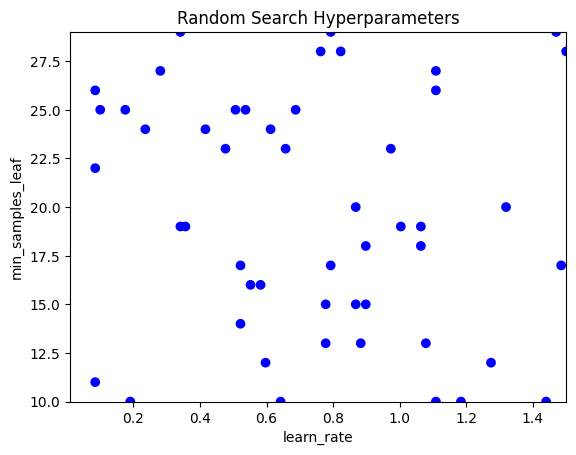

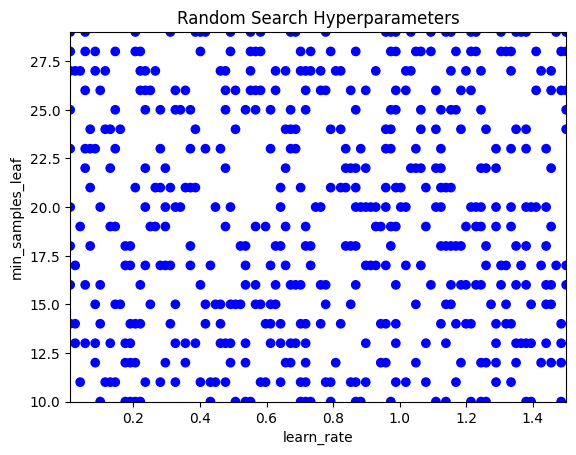

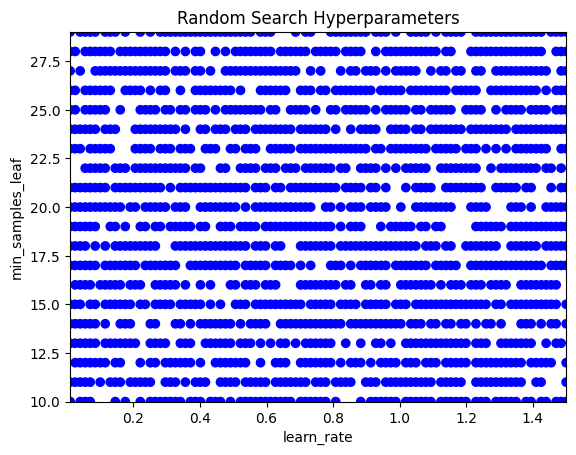

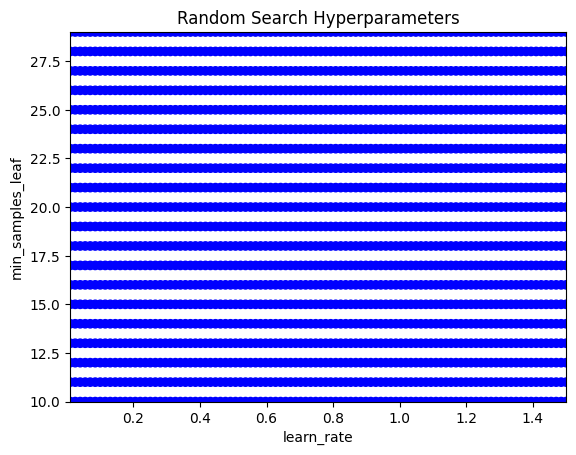

In [11]:
learn_rate_list = list(np.linspace(0.01, 1.5, 100))
min_samples_list = list(range(10, 30))
combinations_list = [list(x) for x in product(learn_rate_list, min_samples_list)]

# Confirm how many hyperparameter combinations & print
number_combs = len(combinations_list)
print(number_combs)

# Sample and visualise specified combinations
for x in [50, 500, 1500]:
    sample_and_visualize_hyperparameters(x)

# Sample all the hyperparameter combinations & visualise
sample_and_visualize_hyperparameters(number_combs)

# **Randomized Search CV**

### ***Exercise: The RandomizedSearchCV Object***

Just like the **`GridSearchCV`** library from Scikit Learn, **`RandomizedSearchCV`** provides many useful features to assist with efficiently undertaking a random search. You're going to create a **`RandomizedSearchCV`** object, making the small adjustment needed from the **`GridSearchCV`** object.

The desired options are:

- A default Gradient Boosting Classifier Estimator
- 5-fold cross validation
- Use accuracy to score the models
- Use 4 cores for processing in parallel
- Ensure you refit the best model and return training scores
- Randomly sample 10 models

The hyperparameter grid should be for `learning_rate` (150 values between 0.1 and 2) and `min_samples_leaf` (all values between and including 20 and 64).

#### ***Instructions***

* Create a parameter grid as specified in the context above.
* Create a `RandomizedSearchCV` object as outlined in the context above.
* Fit the `RandomizedSearchCV` object to the training data.
- Print the values chosen by the modeling process for both hyperparameters.

In [5]:
# Create the parameter grid
param_grid = {'learning_rate': np.linspace(0.1,2,150), 'min_samples_leaf': list(range(20, 65))}

# Create a random search object
random_GBM_class = RandomizedSearchCV(estimator=GradientBoostingClassifier(),
                                      param_distributions=param_grid,
                                      n_iter=10,
                                      scoring='accuracy',
                                      n_jobs=4,
                                      cv=5,
                                      refit=True,
                                      return_train_score=True)

# Fit to the training data
random_GBM_class.fit(X_train, y_train)

# Print the values used for both hyperparameters
print(random_GBM_class.cv_results_['param_learning_rate'])
print(random_GBM_class.cv_results_['param_min_samples_leaf'])

[0.125503355704698 2.0 1.2731543624161075 1.4261744966442953
 1.8724832214765101 0.2530201342281879 1.4261744966442953
 0.7375838926174496 1.6174496644295302 1.3241610738255034]
[37 53 38 50 28 49 38 44 34 45]


# **Exercise: RandomSearchCV in Scikit Learn**

Let's practice building a **`RandomizedSearchCV`** object using Scikit Learn.

The hyperparameter grid should be for `max_depth` (all values between and including 5 and 25) and `max_features` ('auto' and 'sqrt').

The desired options for the **`RandomizedSearchCV`** object are:

- A **`RandomForestClassifier`** Estimator with `n_estimators` of 80.

- 3-fold cross validation (`cv`)

- Use `roc_auc` to score the models

- Use 4 cores for processing in parallel (`n_jobs`)

- Ensure you refit the best model and return training scores

- Only sample 5 models for efficiency (`n_iter`)

Remember, to extract the chosen hyperparameters these are found in `cv_results_` with a column per hyperparameter. For example, the column for the hyperparameter criterion would be `param_criterion`.

#### ***Instructions***

- Create a hyperparameter grid as specified in the context above.

- Create a **`RandomizedSearchCV`** object as outlined in the context above.
- Fit the **`RandomizedSearchCV`** object to the training data.
- Index into the `cv_results_` object to print the values chosen by the modeling process for both hyperparameters (`max_depth` and `max_features`).

In [7]:
# Create the parameter grid
param_grid = {'max_depth': list(range(5,26)), 'max_features': ['sqrt']}

# Create a random search object
random_rf_class = RandomizedSearchCV(
    estimator=RandomForestClassifier(n_estimators=80),
    param_distributions=param_grid, n_iter=5,
    scoring='roc_auc', n_jobs=4, cv=3, refit=True, return_train_score=True)

# Fit to the training data
random_rf_class.fit(X_train, y_train)

# Print the values used for both hyperparameters
print(random_rf_class.cv_results_['param_max_depth'])
print(random_rf_class.cv_results_['param_max_features'])

[14 6 19 20 7]
['sqrt' 'sqrt' 'sqrt' 'sqrt' 'sqrt']


# **GridSearch vs RandomSearch**

### ***Exercise: Grid and Random Search Side by Side***

Visualizing the search space of random and grid search together allows you to easily see the coverage that each technique has and therefore brings to life their specific advantages and disadvantages.

In this exercise, you will sample hyperparameter combinations in a grid search way as well as a random search way, then plot these to see the difference.

#### ***Instructions***

- Sample (by slicing) 300 hyperparameter combinations for a grid search from `combinations_list` into two lists and print the result.

- Let's randomly sample too. Create a list of every index in `combinations_list` to sample from using `range()`

- Use **`np.random.choice()`** to sample 300 combinations. The first two arguments are a list to sample from and the number of samples.

- Now use the list of random indexes to index into `combinations_list` using a list comprehension.

- Use `visualize_search()` function to visualize the two sampling methodologies. The first argument is your grid combinations, the second argument is the random combinations you created.

In [9]:
def visualize_search(grid_combinations_chosen, random_combinations_chosen):
  grid_y, grid_x = [x[0] for x in grid_combinations_chosen], [x[1] for x in grid_combinations_chosen]
  rand_y, rand_x = [x[0] for x in random_combinations_chosen], [x[1] for x in random_combinations_chosen]

  # Plot all together
  plt.scatter(grid_y + rand_y, grid_x + rand_x, c=['red']*300 + ['blue']*300)
  plt.gca().set(xlabel='learn_rate', ylabel='min_samples_leaf', title='Grid and Random Search Hyperparameters')
  plt.gca().set_xlim(x_lims)
  plt.gca().set_ylim(y_lims)
  plt.show()

x_lims = [0.01, 3.0]
y_lims = [5, 24]

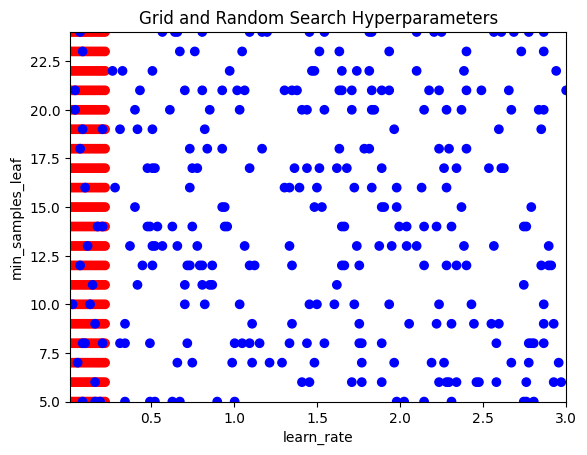

In [10]:
learn_rate_list = list(np.linspace(0.01, 3.0, 200))
min_samples_list = list(range(5, 25))
combinations_list = [list(x) for x in product(learn_rate_list, min_samples_list)]

# Sample grid coordinates
grid_combinations_chosen = combinations_list[0:300]

# Create a list of sample indexes
sample_indexes = list(range(0,len(combinations_list)))

# Randomly sample 300 indexes
random_indexes = np.random.choice(sample_indexes, 300, replace=False)

# Use indexes to create random sample
random_combinations_chosen = [combinations_list[index] for index in random_indexes]

# Call the function to produce the visualization
visualize_search(grid_combinations_chosen, random_combinations_chosen)

# **Informed serch: Coarse to fine**

The process is:
1. Random search
2. Find promising areas
3. Grid search in the smaller area
4. Continue until optimal score obtained

### ***Exercise: Visualizing Coarse to Fine***

You're going to undertake the first part of a Coarse to Fine search. This involves analyzing the results of an initial random search that took place over a large search space, then deciding what would be the next logical step to make your hyperparameter search finer.

You have available:

- `combinations_list` - a list of the possible hyperparameter combinations the random search was undertaken on.

- `results_df` - a DataFrame that has each hyperparameter combination and the resulting accuracy of all 500 trials. **Each hyperparameter is a column**, with the header the hyperparameter name.

- `visualize_hyperparameter()` - a function that takes in a column of the DataFrame (as a string) and produces a scatter plot of this column's values compared to the accuracy scores. An example call of the function would be `visualize_hyperparameter('accuracy')`


#### ***Instructions***

- Confirm (by printing out) the size of the `combinations_list`, justifying the need to start with a random search.
- Sort the `results_df` by accuracy values and print the top 10 rows. Are there clear insights? Beware a small sample size!
- Confirm (by printing out) which hyperparameters were used in this search. These are the column names in `results_df`.

- Call `visualize_hyperparameter()` with each hyperparameter in turn (`max_depth`, `min_samples_leaf`, `learn_rate`). Are there any trends?

10500
    max_depth  min_samples_leaf  learn_rate  accuracy
1          10                14       0.477        97
4           6                12       0.771        97
11          4                16       0.504        96
7          19                10       0.758        96
9          16                13       0.905        96
2           7                14       0.050        96
6           6                10       0.317        96
3           5                12       0.023        96
5          13                11       0.290        96
10         12                13       0.891        96
Index(['max_depth', 'min_samples_leaf', 'learn_rate', 'accuracy'], dtype='object')


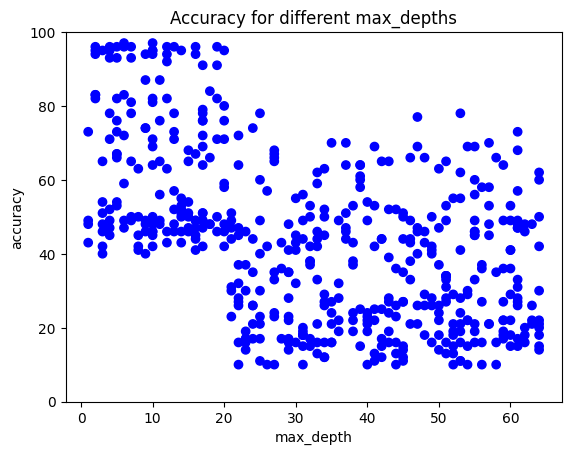

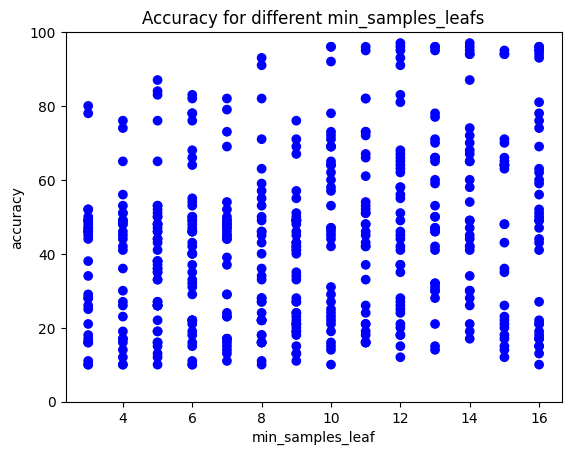

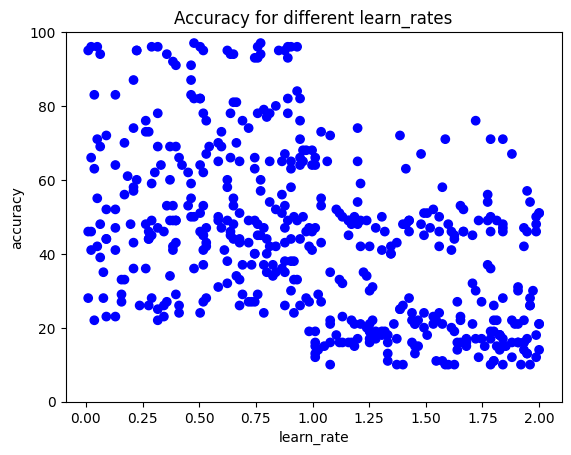

In [17]:
def visualize_hyperparameter(name):
  plt.clf()
  plt.scatter(results_df[name],results_df['accuracy'], c=['blue']*500)
  plt.gca().set(xlabel='{}'.format(name), ylabel='accuracy', title='Accuracy for different {}s'.format(name))
  plt.gca().set_ylim([0,100])
  plt.show()

max_depth_list = list(range(1, 6))
min_samples_list = list(range(3, 17))
learn_rate_list = np.linspace(0.01, 2, 150)
combinations_list = [list(x) for x in product(max_depth_list, min_samples_list, learn_rate_list)]
len(combinations_list)
results_df = pd.read_csv("results_df.csv").drop(columns="Unnamed: 0")

###############################################################################

# Confirm the size of the combinations_list
print(len(combinations_list))

# Sort the results_df by accuracy and print the top 10 rows
print(results_df.sort_values(by='accuracy', ascending=False).head(10))

# Confirm which hyperparameters were used in this search
print(results_df.columns)

# Call visualize_hyperparameter() with each hyperparameter in turn
visualize_hyperparameter('max_depth')
visualize_hyperparameter('min_samples_leaf')
visualize_hyperparameter('learn_rate')


Results clearly seem better when `max_depth` is below 20. `learn_rates` smaller than 1 seem to perform well too. There is not a strong trend for `min_samples leaf` though.


### ***Exercise: Coarse to Fine Iterations***

You will now visualize the first random search undertaken, construct a tighter grid and check the results. You will have available:

- `results_df` - a DataFrame that has the hyperparameter combination and the resulting accuracy of all 500 trials. Only the hyperparameters that had the strongest visualizations from the previous exercise are included (`max_depth` and `learn_rate`)

- `visualize_first()` - This function takes no arguments but will visualize each of your hyperparameters against accuracy for your first random search.

#### **Instructions**

- Use the `visualize_first()` function to check the values of `max_depth` and `learn_rate` that tend to perform better. A convenient red line will be added to make this explicit.



In [19]:
def visualize_first():
  for name in results_df.columns[0:2]:
    plt.clf()
    plt.scatter(results_df[name],results_df['accuracy'], c=['blue']*500)
    plt.gca().set(xlabel='{}'.format(name), ylabel='accuracy', title='Accuracy for different {}s'.format(name))
    plt.gca().set_ylim([0,100])
    x_line = 20
    if name == "learn_rate":
      	x_line = 1
    plt.axvline(x=x_line, color="red", linewidth=4)
    plt.show()

def visualize_second():
  for name in results_df2.columns[0:2]:
    plt.clf()
    plt.scatter(results_df2[name],results_df2['accuracy'], c=['blue']*1000)
    plt.gca().set(xlabel='{}'.format(name), ylabel='accuracy', title='Accuracy for different {}s'.format(name))
    plt.gca().set_ylim([0,100])
    plt.show()

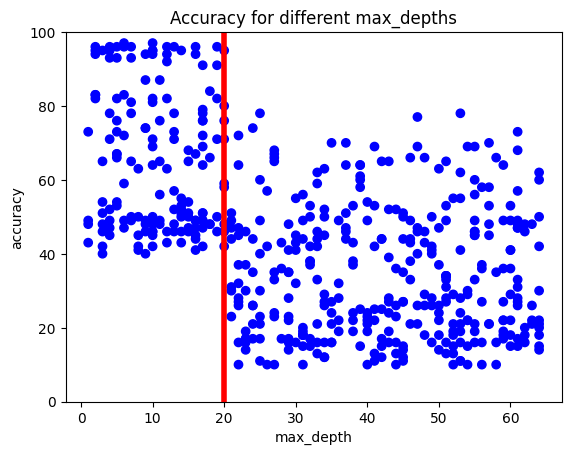

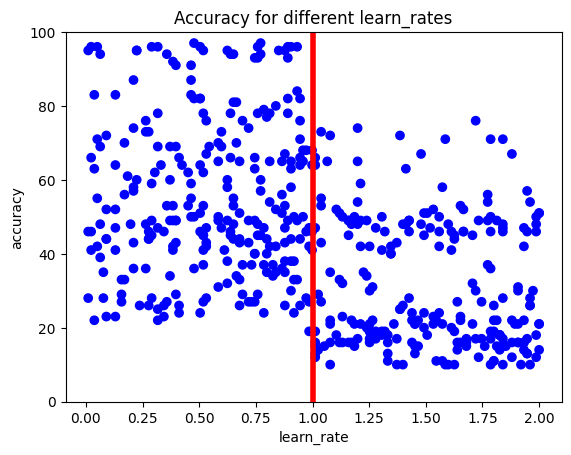

In [20]:
results_df = results_df = pd.read_csv("results_df.csv").drop(columns=["Unnamed: 0", "min_samples_leaf"])

visualize_first()

* Now create a more narrow grid search, testing for `max_depth` values between 1 and 20 and for 50 learning rates between 0.001 and 1.

* We ran the 1,000 model grid search in the background based on those new combinations. Now use the `visualize_second()` function to visualize the second iteration (grid search) and see if there is any improved results. This function takes no arguments, just run it in-place to generate the plots!



In [ ]:
# Use the provided function to visualize the first results
# visualize_first()

# Create some combinations lists & combine:
max_depth_list = list(range(1,21))
learn_rate_list = np.linspace(0.001,1,50)

# Call the function to visualize the second results
visualize_second() # I did not create results_df2

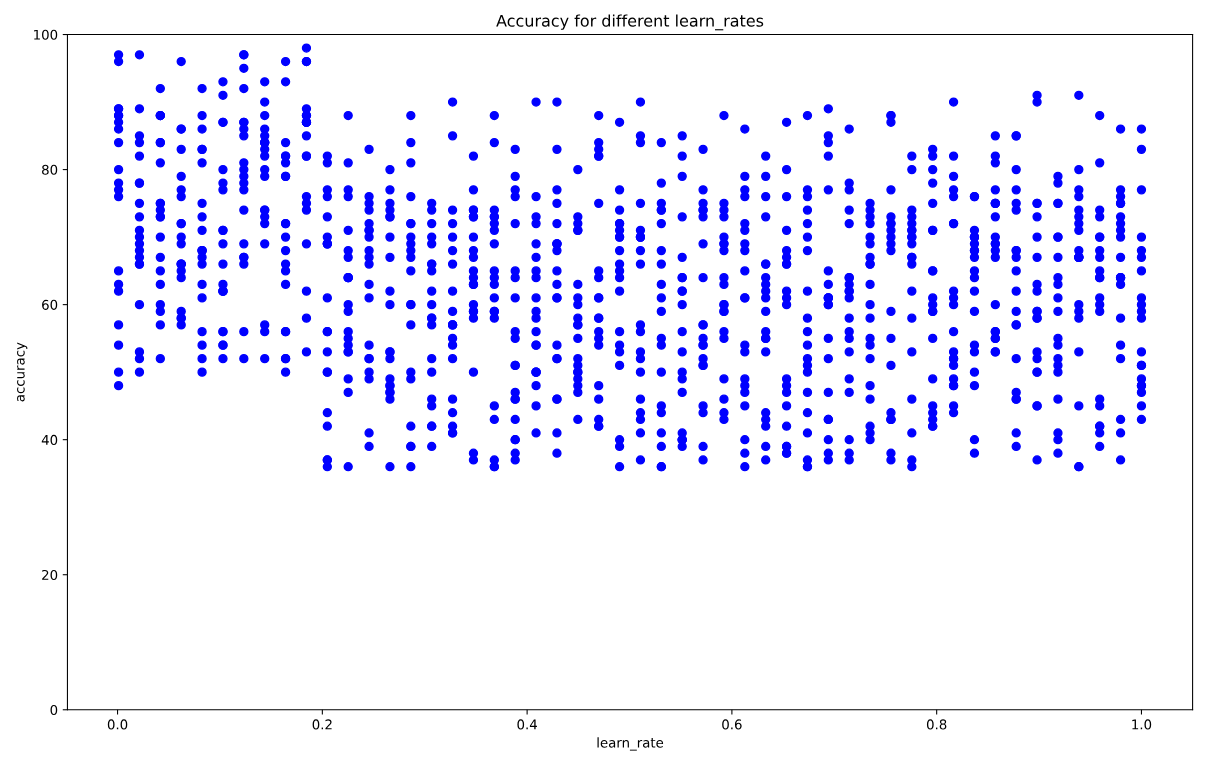

You can see in the second example our results are all generally higher. There also appears to be a bump around `max_depths` between 5 and 10 as well as `learn_rate` less than 0.2 so perhaps there is even more room for improvement

# ***Informed Search: Bayesian***

### ***Exercise: Bayes Rule in Python***

In this exercise you will undertake a practical example of setting up Bayes formula, obtaining new evidence and updating your 'beliefs' in order to get a more accurate result. The example will relate to the likelihood that someone will close their account for your online software product.

These are the probabilities we know:

- 7% (0.07) of people are likely to close their account next month
- 15% (0.15) of people with accounts are unhappy with your product (you don't know who though!)
- 35% (0.35) of people who are likely to close their account are unhappy with your product

#### ***Instructions***

* Assign the different probabilities (as decimals) to variables. `p_unhappy` is the likelihood someone is unhappy, `p_unhappy_close` is the probability that someone is unhappy with the product, given they are going to close their account.

* Assign the probability that someone will close their account next month to the variable `p_close` as a decimal.

* You interview one of your customers and discover they are unhappy. What is the probability they will close their account, now that you know this evidence? Assign the result to `p_close_unhappy` and print it.

In [21]:
# Assign probabilities to variables
p_unhappy = 0.15
p_unhappy_close = 0.35

# Probabiliy someone will close
p_close = 0.07

# Probability unhappy person will close
p_close_unhappy = (p_unhappy_close * p_close) / p_unhappy
print(p_close_unhappy)

0.16333333333333336


In [22]:
! pip install hyperopt

### ***Exercise: Bayesian Hyperparameter tuning with Hyperopt***

In this example you will set up and run a Bayesian hyperparameter optimization process using the package `Hyperopt` (already imported as `hp` for you). You will set up the domain (which is similar to setting up the grid for a grid search), then set up the objective function. Finally, you will run the optimizer over 20 iterations.

You will need to set up the domain using values:

- `max_depth` using quniform distribution (between 2 and 10, increasing by 2)
- `learning_rate` using uniform distribution (0.001 to 0.9)
Note that for the purpose of this exercise, this process was reduced in data sample size and hyperopt & GBM iterations. If you are trying out this method by yourself on your own machine, try a larger search space, more trials, more cvs and a larger dataset size to really see this in action!

#### ***Instructions***

- Set up a `space` dictionary using the domain mentioned above.
- Set up the objective function using a gradient boosting classifier.
- Run the algorithm for 20 evaluations (just use the default, suggested algorithm from the slides).

In [27]:
from hyperopt import fmin, tpe, Trials, STATUS_OK, hp

# Set up space dictionary with specified hyperparameters
space = {'max_depth': hp.quniform ('max_depth', 2, 10, 2),'learning_rate': hp.uniform('learning_rate', 0.001, 0.9)}

# Set up objective function
def objective(params):
    params = {'max_depth': int(params['max_depth']),'learning_rate': params['learning_rate']}
    gbm_clf = GradientBoostingClassifier(n_estimators=100, **params)
    best_score = cross_val_score(gbm_clf, X_train, y_train, scoring='accuracy', cv=2, n_jobs=4).mean()
    loss = 1 - best_score
    return loss

# Run the algorithm
best = fmin(fn=objective,space=space, max_evals=20, rstate=np.random.default_rng(42), algo=tpe.suggest)
print(best)

100%|██████████| 20/20 [07:19<00:00, 21.99s/trial, best loss: 0.17941666666666667]
{'learning_rate': np.float64(0.038093061276450534), 'max_depth': np.float64(2.0)}


# **Informed methods: Genetic Algorithms**

In [30]:
! pip install tpot

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 7.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.1/215.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.1 MB/s eta 0:00:00
  Created wheel for configspace: filename=configspace-1.2.1-py3-none-any.whl size=115990 sha256=ee13e72bebf07a055d2c7e6ccc30c27483f78c74d2480e9b4d01f1c629320950
  Stored in directory: /root/.cache/pip/wheels/bb/a5/10/517a06e

### ***Exercise: Genetic Hyperparameter Tuning with TPOT***

You're going to undertake a simple example of genetic hyperparameter tuning. TPOT is a very powerful library that has a lot of features. You're just scratching the surface in this lesson, but you are highly encouraged to explore in your own time.

This is a very small example. In real life, TPOT is designed to be run for many hours to find the best model. You would have a much larger population and offspring size as well as hundreds more generations to find a good model.

You will create the estimator, fit the estimator to the training data and then score this on the test data.

For this example we wish to use:

- 3 generations
- 4 in the population size
- 3 offspring in each generation
- accuracy for scoring

A `random_state `of 2 has been set for consistency of results.

#### ***Instructions***

- Assign the values outlined in the context to the inputs for `tpot_clf`.
- Create the `tpot_clf` classifier with the correct inputs.
- Fit the classifier to the training data (`X_train` & `y_train`).
- Use the fitted classifier to score on the test set (`X_test` & `y_test`)

In [7]:
from tpot import TPOTClassifier
from sklearn.metrics import accuracy_score

# Assign the values outlined to the inputs
number_generations = 3
population_size = 4
offspring_size = 3
scoring_function = 'accuracy'

# Create the TPOT classifier (no offspring_size)
tpot_clf = TPOTClassifier(
    generations=3,
    population_size=4,
    random_state=2,
    cv=2
)
tpot_clf.fit(X_train, y_train)
y_pred = tpot_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:45559
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45375'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44501 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44501
INFO:distributed.core:Starting established connection to tcp://127.0.0.1

Accuracy: 0.8243333333333334


You can see in the output the score produced by the chosen model (in this case a version of Naive Bayes) over each generation, and then the final accuracy score with the hyperparameters chosen for the final model. This is a great first example of using TPOT for automated hyperparameter tuning.

### ***Exercise: Analysing TPOT's stability***

You will now see the random nature of TPOT by constructing the classifier with different random states and seeing what model is found to be best by the algorithm. This assists to see that TPOT is quite unstable when not run for a reasonable amount of time.

#### ***Instructions***

1. Create the TPOT classifier, fit to the data and score using a `random_state` of 42.



2. Now try using a `random_state` of 122. The numbers don't mean anything special, but should produce different results.

3. Finally try using the `random_state` of 99. See how there is a different result again?

In [ ]:
# Create the tpot classifier
tpot_clf = TPOTClassifier(generations=2, population_size=4, offspring_size=3, scoring='accuracy', cv=2,
                          verbosity=2, random_state=122)

# Fit the classifier to the training data
tpot_clf.fit(X_train, y_train)

# Score on the test set
print(tpot_clf.score(X_test, y_test))



```
Optimization Progress:   0%|          | 0/10 [00:00<?, ?pipeline/s]
Optimization Progress:  20%|##        | 2/10 [00:00<00:01,  7.73pipeline/s]
Optimization Progress:  30%|###       | 3/10 [00:00<00:01,  5.93pipeline/s]
Optimization Progress:  40%|####      | 4/10 [00:00<00:00,  6.58pipeline/s]
Optimization Progress:  50%|#####     | 5/10 [00:00<00:00,  5.34pipeline/s]
                                                                           
    Generation 1 - Current best internal CV score: 0.7775000000000001
    
Optimization Progress:  70%|#######   | 7/10 [00:00<00:00,  5.34pipeline/s]
Optimization Progress:  70%|#######   | 7/10 [00:01<00:00,  6.38pipeline/s]
Optimization Progress:  90%|######### | 9/10 [00:01<00:00,  6.95pipeline/s]
                                                                           
    Generation 2 - Current best internal CV score: 0.7775000000000001
    
Optimization Progress: 100%|##########| 10/10 [00:01<00:00,  6.95pipeline/s]
                                                                            
    Best pipeline: RandomForestClassifier(input_matrix, bootstrap=True, criterion=gini, max_features=0.2, min_samples_leaf=8, min_samples_split=4, n_estimators=100)
    0.73
```


```

Optimization Progress:   0%|          | 0/10 [00:00<?, ?pipeline/s]
Optimization Progress:  40%|####      | 4/10 [00:00<00:00, 29.56pipeline/s]
Optimization Progress:  70%|#######   | 7/10 [00:00<00:00,  9.71pipeline/s]
                                                                           
    Generation 1 - Current best internal CV score: 0.7825
    
Optimization Progress:  70%|#######   | 7/10 [00:00<00:00,  9.71pipeline/s]
Optimization Progress:  90%|######### | 9/10 [00:00<00:00, 10.57pipeline/s]
                                                                           
    Generation 2 - Current best internal CV score: 0.7825
    
Optimization Progress: 100%|##########| 10/10 [00:00<00:00, 10.57pipeline/s]
                                                                            
    Best pipeline: BernoulliNB(input_matrix, alpha=0.01, fit_prior=True)
    0.76
```




```

Optimization Progress:   0%|          | 0/10 [00:00<?, ?pipeline/s]
Optimization Progress:  40%|####      | 4/10 [00:00<00:00,  6.85pipeline/s]
Optimization Progress:  50%|#####     | 5/10 [00:00<00:00,  5.04pipeline/s]
Optimization Progress:  60%|######    | 6/10 [00:01<00:01,  3.19pipeline/s]
                                                                           
    Generation 1 - Current best internal CV score: 0.7825
    
Optimization Progress:  70%|#######   | 7/10 [00:01<00:00,  3.19pipeline/s]
Optimization Progress:  70%|#######   | 7/10 [00:01<00:00,  3.27pipeline/s]
Optimization Progress:  80%|########  | 8/10 [00:02<00:00,  2.66pipeline/s]
Optimization Progress: 100%|##########| 10/10 [00:02<00:00,  3.74pipeline/s]
                                                                            
    Generation 2 - Current best internal CV score: 0.7825
    
Optimization Progress: 100%|##########| 10/10 [00:02<00:00,  3.74pipeline/s]
                                                                            
    Best pipeline: BernoulliNB(input_matrix, alpha=0.001, fit_prior=True)
    0.76
```

You can see that TPOT is quite unstable when only running with low generations, population size and offspring. The first model chosen was a Decision Tree, then a K-nearest Neighbor model and finally a Random Forest. Increasing the generations, population size and offspring and running this for a long time will assist to produce better models and more stable results. Don't hesitate to try it yourself on your own machine!




